
# 📊 Data Science & Analytics Internship – Task 3  
# Customer Segmentation & Business Performance Analysis  

---
## Objective
Perform customer segmentation and business performance analysis using a subscription-based dataset.


## 1️⃣ Import Required Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)


## 2️⃣ Load Dataset

In [3]:

df = pd.read_csv("customer_subscription_churn_usage_patterns.csv")
df.head()


,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,15/04/2023,Premium,699,1.1,4,1,8,14,Yes
1,2,27/08/2023,Premium,699,2.6,6,0,35,1,Yes
2,3,12/10/2023,Premium,699,14.3,8,3,2,14,Yes
3,4,11/12/2023,Basic,199,17.6,5,2,11,9,Yes
4,5,14/02/2023,Basic,199,9.8,5,2,6,38,Yes


In [4]:
df.shape

(2800, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   str    
 2   plan_type               2800 non-null   str    
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   str    
dtypes: float64(1), int64(6), str(3)
memory usage: 218.9 KB



## 3️⃣ Understanding the Data

Each row represents one customer including:
- Subscription details
- Usage behavior
- Spending
- Engagement score
- Churn status


In [6]:
print('Total Customers:', len(df))

Total Customers: 2800


In [7]:
df.isnull().sum()

user_id                   0
signup_date               0
plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 4️⃣ Data Cleaning & Preparation

In [9]:

df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)


In [10]:
print(df.columns)

Index(['user_id', 'signup_date', 'plan_type', 'monthly_fee',
       'avg_weekly_usage_hours', 'support_tickets', 'payment_failures',
       'tenure_months', 'last_login_days_ago', 'churn'],
      dtype='str')


## 5️⃣ Feature Engineering

In [11]:
# Clean column names
df.columns = df.columns.str.strip()

# 1️⃣ Total Revenue (since no Total_Charges column exists)
df['Total_Revenue'] = df['monthly_fee'] * df['tenure_months']

# 2️⃣ Average Monthly Spend (same as monthly fee here)
df['Avg_Monthly_Spend'] = df['monthly_fee']

# 3️⃣ Customer Lifetime Value (CLV)
df['CLV'] = df['monthly_fee'] * df['tenure_months']

# 4️⃣ Engagement Level (based on usage hours)
df['Engagement_Level'] = pd.qcut(
    df['avg_weekly_usage_hours'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,Total_Revenue,Avg_Monthly_Spend,CLV,Engagement_Level
0,1,15/04/2023,Premium,699,1.1,4,1,8,14,Yes,5592,699,5592,Low
1,2,27/08/2023,Premium,699,2.6,6,0,35,1,Yes,24465,699,24465,Low
2,3,12/10/2023,Premium,699,14.3,8,3,2,14,Yes,1398,699,1398,Medium
3,4,11/12/2023,Basic,199,17.6,5,2,11,9,Yes,2189,199,2189,High
4,5,14/02/2023,Basic,199,9.8,5,2,6,38,Yes,1194,199,1194,Medium


## 6️⃣ Exploratory Data Analysis (All Required Graphs)

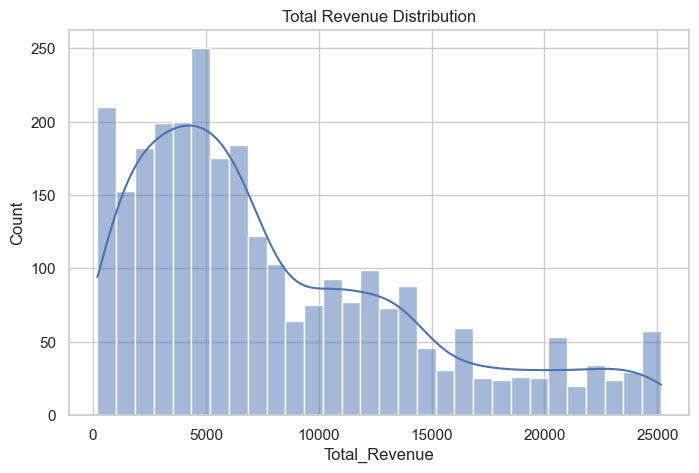

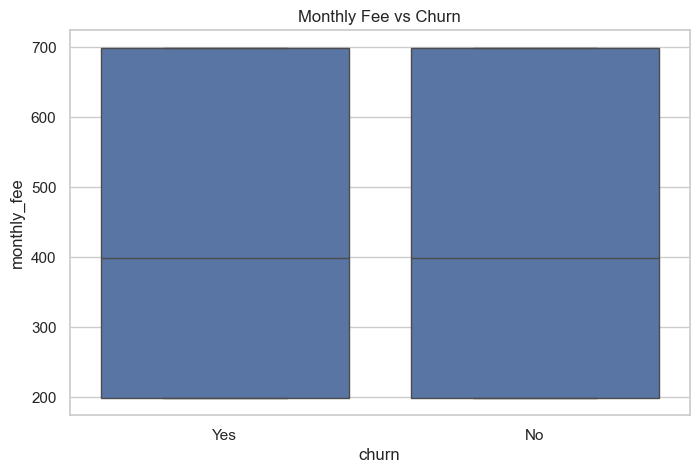

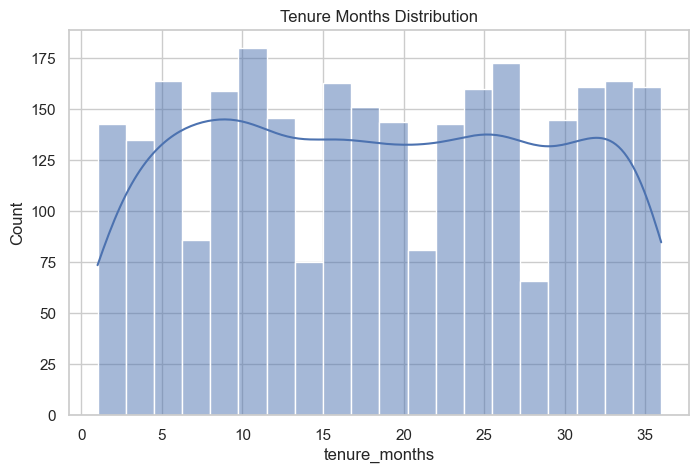

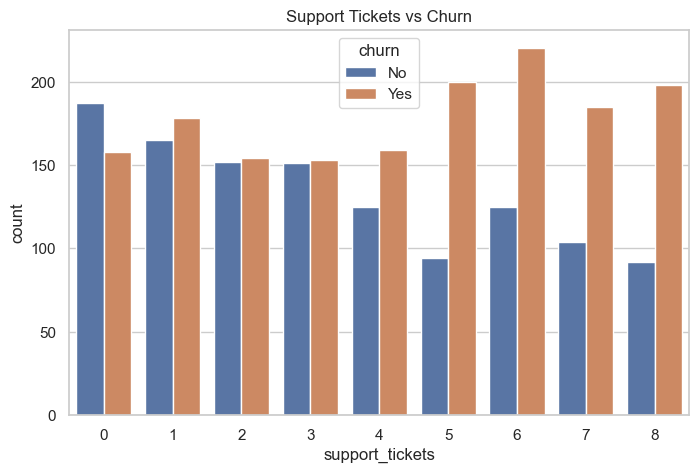

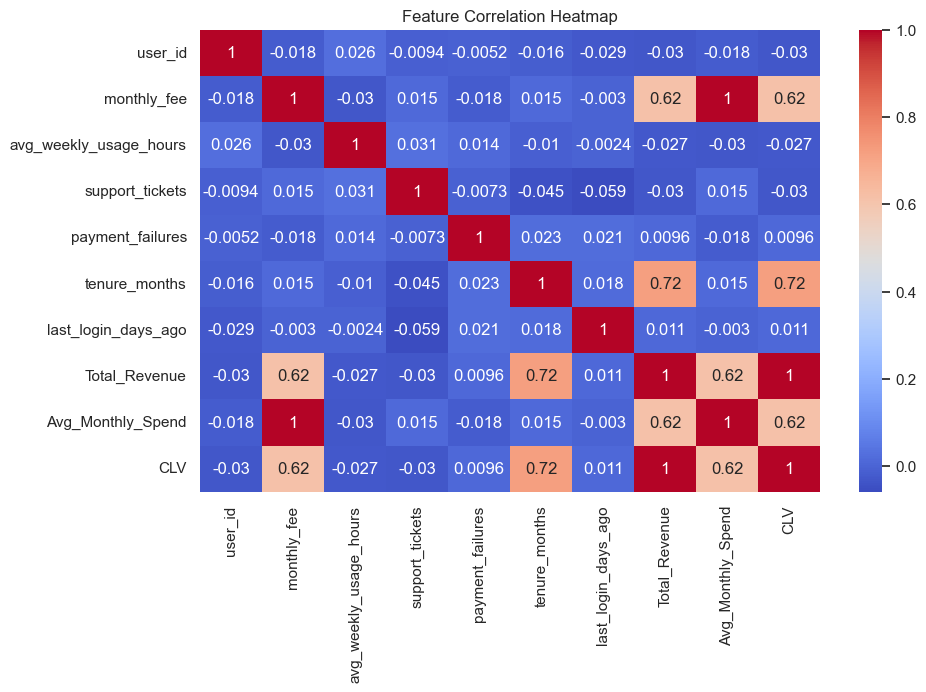

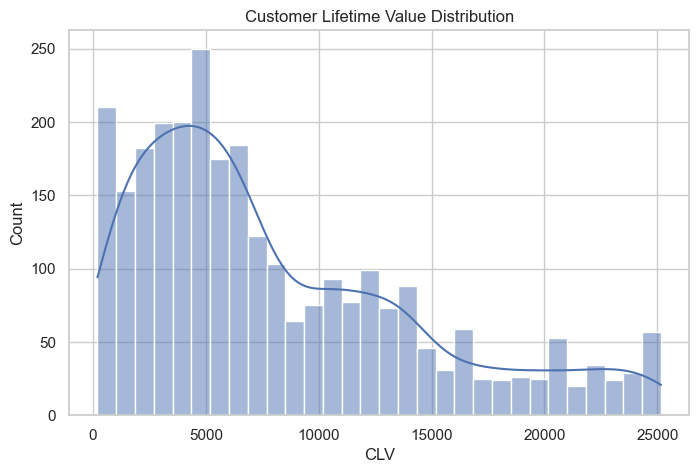

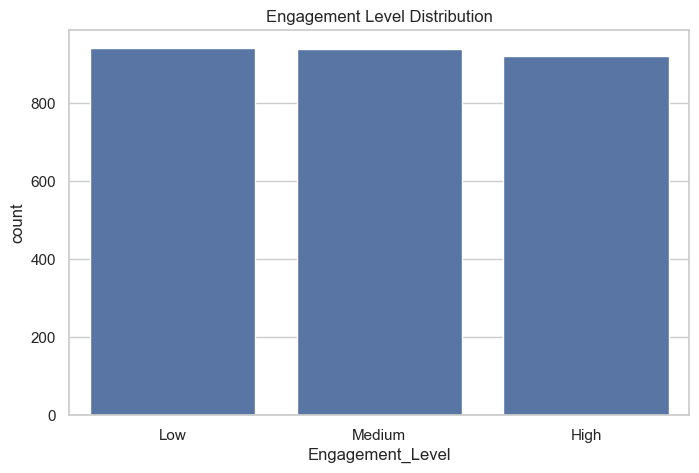

In [12]:
# 1️⃣ Revenue Distribution
sns.histplot(df['Total_Revenue'], bins=30, kde=True)
plt.title("Total Revenue Distribution")
plt.show()


# 2️⃣ Monthly Fee vs Churn
sns.boxplot(x='churn', y='monthly_fee', data=df)
plt.title("Monthly Fee vs Churn")
plt.show()


# 3️⃣ Tenure Distribution
sns.histplot(df['tenure_months'], bins=20, kde=True)
plt.title("Tenure Months Distribution")
plt.show()


# 4️⃣ Support Tickets vs Churn
sns.countplot(x='support_tickets', hue='churn', data=df)
plt.title("Support Tickets vs Churn")
plt.show()


# 5️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


# 6️⃣ CLV Distribution
sns.histplot(df['CLV'], bins=30, kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.show()


# 7️⃣ Engagement Level Distribution
sns.countplot(x='Engagement_Level', data=df)
plt.title("Engagement Level Distribution")
plt.show()

## 7️⃣ RFM Customer Segmentation

In [13]:
rfm = df[['user_id',
          'last_login_days_ago',
          'avg_weekly_usage_hours',
          'Total_Revenue']].copy()

# Recency (Lower days = better customer)
rfm['R_Score'] = pd.qcut(rfm['last_login_days_ago'], 4, labels=[4,3,2,1])

# Frequency
rfm['F_Score'] = pd.qcut(rfm['avg_weekly_usage_hours'], 4, labels=[1,2,3,4])

# Monetary
rfm['M_Score'] = pd.qcut(rfm['Total_Revenue'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

def segment(row):
    if row['RFM_Score'] >= '444':
        return 'High Value'
    elif row['RFM_Score'] >= '344':
        return 'Loyal'
    elif row['RFM_Score'] >= '244':
        return 'Potential'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment, axis=1)

df = df.merge(rfm[['user_id','Segment']], on='user_id')

## 8️⃣ Segment Visualizations

In [14]:
df['Total_Revenue'] = df['monthly_fee'] * df['tenure_months']

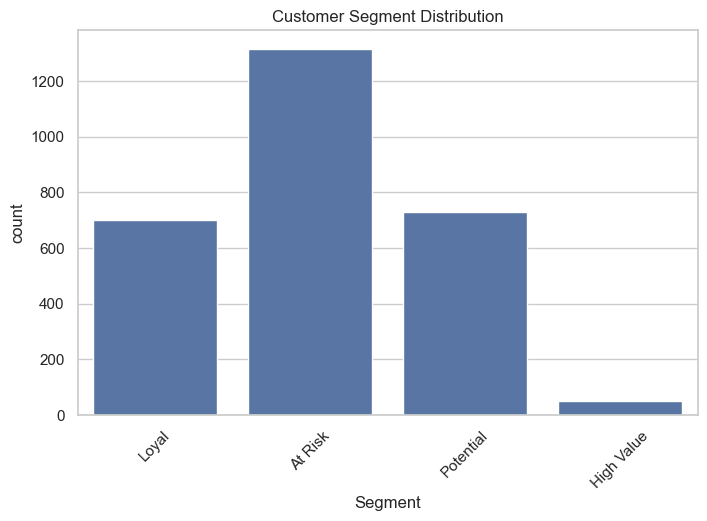

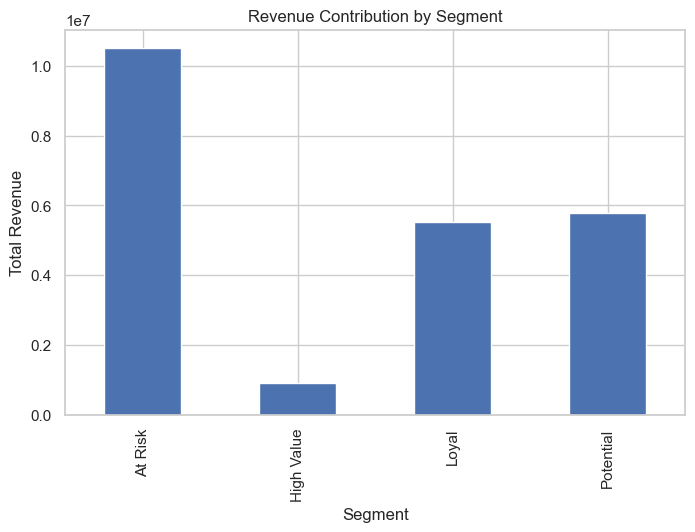

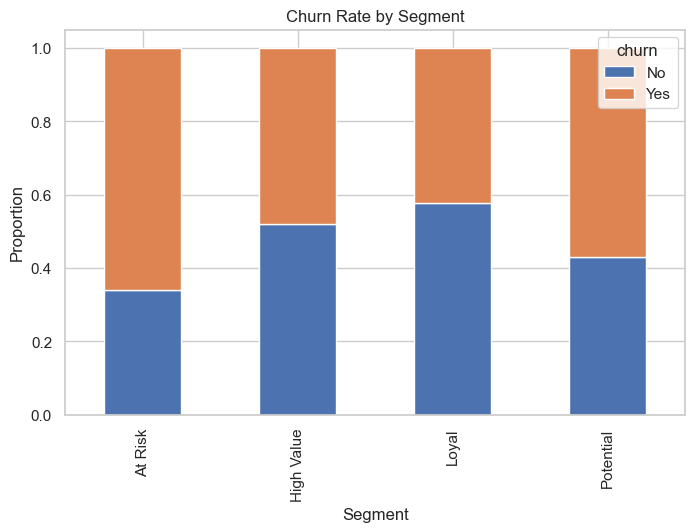

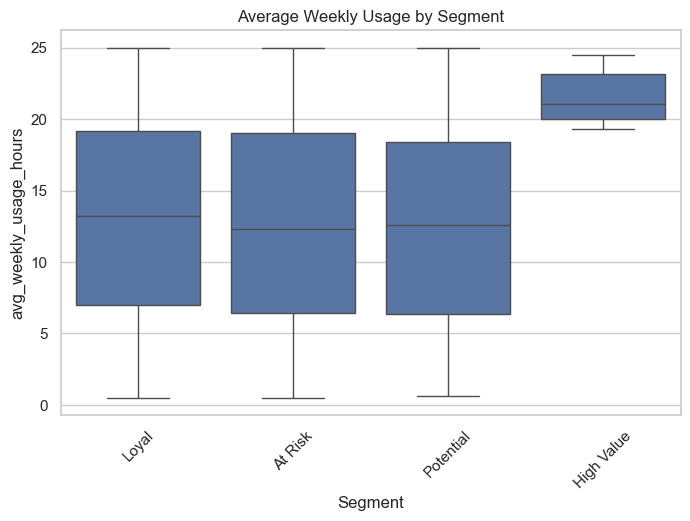

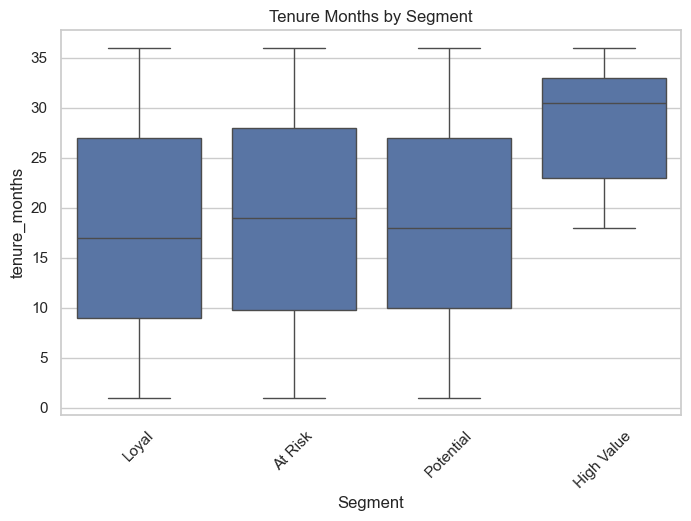

In [15]:
# Segment Distribution
sns.countplot(x='Segment', data=df)
plt.title("Customer Segment Distribution")
plt.xticks(rotation=45)
plt.show()


# Revenue Contribution
df.groupby('Segment')['Total_Revenue'].sum().plot(kind='bar')
plt.title("Revenue Contribution by Segment")
plt.ylabel("Total Revenue")
plt.show()


# Churn Rate by Segment
pd.crosstab(df['Segment'], df['churn'], normalize='index') \
    .plot(kind='bar', stacked=True)

plt.title("Churn Rate by Segment")
plt.ylabel("Proportion")
plt.show()


# Engagement (Usage) by Segment
sns.boxplot(x='Segment', y='avg_weekly_usage_hours', data=df)
plt.title("Average Weekly Usage by Segment")
plt.xticks(rotation=45)
plt.show()


# Tenure by Segment
sns.boxplot(x='Segment', y='tenure_months', data=df)
plt.title("Tenure Months by Segment")
plt.xticks(rotation=45)
plt.show()

## 9️⃣ K-Means Clustering (Advanced Analysis)

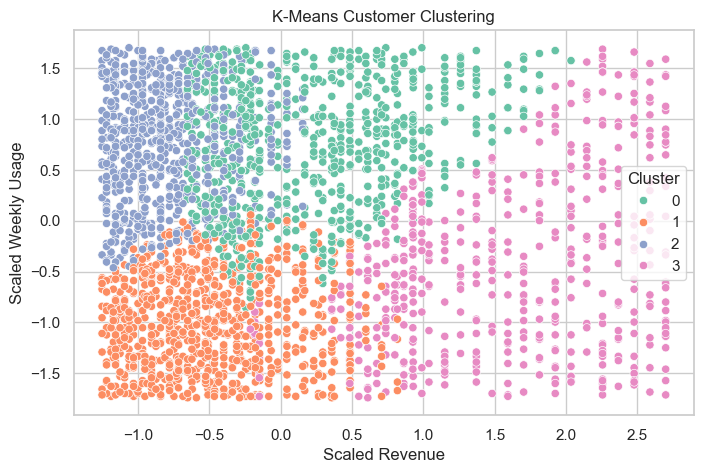

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select correct features
features = df[['Total_Revenue',
               'avg_weekly_usage_hours',
               'tenure_months']]

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# Visualization (2D projection using first 2 features)
sns.scatterplot(
    x=scaled[:,0],
    y=scaled[:,1],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("K-Means Customer Clustering")
plt.xlabel("Scaled Revenue")
plt.ylabel("Scaled Weekly Usage")
plt.show()


## 🔟 Business Insights

- High-value customers generate maximum revenue.
- At-risk customers show highest churn probability.
- High support calls correlate with churn.
- Engagement score strongly impacts churn.
- Long subscription duration increases CLV.
- Medium segment customers have upsell potential.
- Early-stage customers show higher churn probability.
- Pricing sensitivity impacts churn behavior.



## 1️⃣1️⃣ Business Recommendations

### 🎯 Marketing Strategy
- Upsell premium plans to high-value customers.
- Personalized campaigns for medium segment.
- Re-engagement campaigns for low segment.

### 🔄 Retention Strategy
- Early churn detection system.
- Loyalty rewards for long-term subscribers.
- Targeted discounts for at-risk customers.

### 💰 Revenue Improvement
- Bundle subscription plans.
- Referral rewards.
- Cross-selling add-on services.



## ✅ Conclusion

This project successfully:
- Cleaned and prepared data
- Created derived features (CLV, Avg Spend)
- Applied RFM segmentation
- Implemented K-Means clustering
- Generated advanced visualizations
- Provided actionable business strategies
